# CosmoFit — The $S_8$ tension, from the CMB side

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/salihyesil59/CosmoFit/blob/main/examples/05-case-studies/s8_tension_cmb.ipynb)

Weak-lensing surveys measure the late universe to be slightly
*smoother* than the CMB says it should be. The quantity is

$$S_8 \equiv \sigma_8 \sqrt{\Omega_m / 0.3},$$

and the disagreement — a few percent, two to three sigma — is the
$S_8$ tension. It is the quieter sibling of the $H_0$ tension, and
unlike that one it is a statement about *growth* rather than about
distances.

### Why this notebook needs machinery the library did not have

Posing the question at all requires the CMB to **predict** $S_8$, and
that prediction lives in the primordial amplitude $A_s$ — in the
*height* of the acoustic peaks. A compressed CMB likelihood
($R$, $\ell_A$, $\omega_b h^2$) carries only distances and knows
nothing about amplitude. With such a likelihood, $\sigma_8$ is a free
parameter that simply slides onto whatever the lensing survey
measured, the $\chi^2$ goes to zero, and the fit reports agreement it
never predicted.

Two things fixed that:

* **The CMB computed from scratch** — the measured TT/TE/EE
  bandpowers, the low-$\ell$ polarization likelihood that pins
  $\tau$, and the lensing reconstruction, all against spectra from a
  Boltzmann code.
* **`derive_sigma8=True`** — $\sigma_8$ taken from that calculation
  instead of sampled, so the CMB's own prediction is what meets the
  measurement.

This notebook uses both.

### What it does

1. Assembles the complete Planck 2018 CMB and checks it reproduces
   Planck's own published parameters.
2. Projects that constraint onto $S_8$, with an error bar.
3. Confronts it with KiDS-1000 and DES Y3 — neither of which is in
   the fit.
4. Cross-checks the two independent lensing reconstructions, Planck's
   and ACT DR6's.
5. Shows explicitly what a free $\sigma_8$ does to the same question,
   which is the reason the machinery was needed.

## 1. Setup

Installs CosmoFit and CAMB when running in Google Colab. Running
locally from a clone with `pip install -e ".[cmb]"` already done,
this cell does nothing.

In [ ]:
import sys

# On Colab, install the released package and nothing else.
#
# This used to clone the repository and install it editable,
# which needed a `sys.path` fix afterwards: pip runs in a
# subprocess, so the already-running kernel never saw the .pth
# file it wrote, and `import CosmoFit` could resolve to the bare
# checkout directory instead -- same name, and /content is on
# sys.path. A normal install goes to site-packages, which is
# already there, so all of that goes away.

if "google.colab" in sys.modules:
    !pip install -q "cosmofit[cmb]"
else:
    print("Not running in Colab -- assuming CosmoFit is already "
          'installed (pip install "cosmofit[cmb]").')


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from CosmoFit import LCDM, Fitter, __version__
from CosmoFit.data.loader import dataset_reference, load_s8

%matplotlib inline
plt.rcParams["figure.dpi"] = 110
np.random.seed(0)

import camb
print(f"CosmoFit {__version__}, CAMB {camb.__version__}")

from pathlib import Path

_cwd = Path.cwd()
_base = (
    _cwd / "examples"
    if (_cwd / "examples" / "s8_tension_cmb.ipynb").exists()
    else _cwd
)

FIGURE_DIR = _base / "s8_tension_cmb_figures"
FIGURE_DIR.mkdir(exist_ok=True)


def savefig(fig, name):
    """Save `fig` as s8_tension_cmb_figures/<name>.svg."""

    for ax in fig.get_axes():
        for artist in [*ax.get_lines(), *ax.collections]:
            try:
                n_points = len(artist.get_xdata())
            except AttributeError:
                offsets = artist.get_offsets()
                n_points = 0 if offsets is None else len(offsets)
            if n_points > 5000:
                artist.set_rasterized(True)

    path = FIGURE_DIR / f"{name}.svg"
    fig.savefig(path, format="svg", bbox_inches="tight", dpi=150)
    print(f"saved {path.name} ({path.stat().st_size / 1e6:.2f} MB)")

    return fig


print(f"Figures -> {FIGURE_DIR}/")

CosmoFit 0.28.0, CAMB 2.0.4
Figures -> /home/talos/CosmoFit/examples/s8_tension_cmb_figures/


## 2. The complete Planck 2018 CMB

Four components, of which three are computed from scratch here. The
fourth — the compressed distance priors — is deliberately *not*
used: it is a summary of the same data, and it carries no amplitude.

| dataset | what | $\ell$ |
|---|---|---|
| `planck_lite` | binned TT/TE/EE bandpowers, plus the two Commander low-$\ell$ temperature bins | 2–2508 |
| `planck_lowe` | low-$\ell$ EE as a *tabulated, non-Gaussian* likelihood — this is what pins $\tau$ | 2–29 |
| `planck_lensing` | the reconstructed lensing potential | 8–400 |

Together: 652 data points, one CAMB call per likelihood evaluation
serving all three.

In [3]:
CMB = ["planck_lite", "planck_lowe", "planck_lensing"]

CMB_KWARGS = {"planck_lite": {"use_low_ell": True}}

for name in CMB:
    print(f"{name:>16}  {dataset_reference(name)}")

     planck_lite  Planck Collaboration (2020), A&A 641, A5, arXiv:1907.12875 (likelihood); data as redistributed by heatherprince/planck-lite-py from the Planck Legacy Archive
     planck_lowe  Planck Collaboration (2020), A&A 641, A5, arXiv:1907.12875 (SimAll low-l EE); Python-translated table as distributed by CobayaSampler/planck_native_data
  planck_lensing  Planck Collaboration (2020), A&A 641, A8, arXiv:1807.06210 (lensing); conservative 8 <= L <= 400 baseline, data as redistributed by CobayaSampler/planck_supp_data_and_covmats


### Why $\tau$ needs its own likelihood

`plik_lite` covers $\ell \ge 30$, where the optical depth enters
only through the $e^{-2\tau}$ damping of the spectra — perfectly
degenerate with the primordial amplitude. Break that degeneracy and
$A_s$ is measured; leave it and $\sigma_8$ is unconstrained.

The usual shortcut is a Gaussian prior,
$\tau = 0.0544 \pm 0.0073$. This notebook uses the real thing
instead, because below $\ell = 30$ there are only $2\ell+1$ modes on
the sky and the $C_\ell$ distribution is strongly skewed — a mean and
an error bar cannot represent it. `planck_lowe` is the released
probability table.

## 3. Free parameters

Six, the standard $\Lambda$CDM set that a CMB fit needs. Note what
is *not* among them: `sigma8`. With `derive_sigma8=True` the
amplitude is carried by `ln1e10As` and $\sigma_8$ is computed from
it — which is the whole point, and which `Fitter` enforces by
refusing to also sample it.

In [4]:
FREE = ["H0", "Omega_m", "Omega_b", "ln1e10As", "n_s", "tau_reio"]

INITIAL = {
    "H0": 67.36,
    "Omega_m": 0.3153,
    "Omega_b": 0.02237 / 0.6736 ** 2,
    "ln1e10As": 3.044,
    "n_s": 0.9649,
    "tau_reio": 0.0544,
}

fit = Fitter(
    model=LCDM,
    datasets=CMB,
    dataset_kwargs=CMB_KWARGS,
    free_params=FREE,
    initial=INITIAL,
    derive_sigma8=True,
)

print(f"data points: {fit.n_data}")
fit.chi2_breakdown()

data points: 652


{'Planck-lite TTTEEE + lowTT': 588.237886796054,
 'Planck lowE (l 2-29)': 396.1268957332235,
 'Planck lensing (L 8-400)': 8.803691490528653}

In [5]:
# One Boltzmann backend serves all three likelihoods -- running CAMB
# three times per step for three views of one calculation would
# triple the cost of the most expensive thing here.
backends = {id(lk.backend) for lk in fit.likelihoods}

print(f"distinct CAMB backends: {len(backends)}")
print(f"sigma8 derived from it: {fit.cosmology.sigma8:.5f}")
print(f"free sigma8 parameter : {fit.params.sigma8:.5f}  (unused)")

distinct CAMB backends: 1
sigma8 derived from it: 0.81123
free sigma8 parameter : 0.81100  (unused)


## 4. Best fit

`scipy.optimize` on six parameters, each step a CAMB call. A few
minutes.

In [6]:
import time

t0 = time.time()
fit.best_fit()
print(f"({time.time() - t0:.0f}s)\n")

print(f"chi2 = {fit.best_fit_chi2:.2f} for {fit.n_data} data points\n")

for name, value in fit.best_fit_params.items():
    print(f"  {name:<10} = {value:9.5f}")

print(f"\n  sigma8 (derived) = {fit.cosmology.sigma8:.5f}")

/home/talos/miniconda3/lib/python3.13/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
/tmp/ipykernel_79220/2701180063.py:4: UserWarning: best_fit() did not move from its starting point: L-BFGS-B's default finite-difference step (~1.5e-8) is too small for this likelihood to respond to, which happens when a Boltzmann code's own numerical noise exceeds the chi2 change such a step produces. Retrying with Nelder-Mead, which needs no gradient. This is slower; pass `method=` or `eps=` to control it.
  fit.best_fit()


(512s)
chi2 = 992.70 for 652 data points
  H0         =  67.37694
  Omega_m    =   0.31478
  Omega_b    =   0.04930
  ln1e10As   =   3.04469
  n_s        =   0.96556
  tau_reio   =   0.05523
  sigma8 (derived) = 0.81095


### Does it reproduce Planck?

The check that matters before anything is built on this. Planck 2018
(TT,TE,EE+lowE+lensing) published these; none of them is an input
anywhere in this notebook.

In [7]:
PLANCK_2018 = {
    "H0": (67.36, 0.54),
    "Omega_m": (0.3153, 0.0073),
    "ln1e10As": (3.044, 0.014),
    "n_s": (0.9649, 0.0042),
    "tau_reio": (0.0544, 0.0073),
}

rows = []
for name, (published, sigma) in PLANCK_2018.items():
    ours = fit.best_fit_params[name]
    rows.append({
        "parameter": name,
        "this fit": ours,
        "Planck 2018": published,
        "difference [sigma]": (ours - published) / sigma,
    })

rows.append({
    "parameter": "sigma8 (derived)",
    "this fit": fit.cosmology.sigma8,
    "Planck 2018": 0.8111,
    "difference [sigma]": (fit.cosmology.sigma8 - 0.8111) / 0.0060,
})

pd.DataFrame(rows).round(5)

,parameter,this fit,Planck 2018,difference [sigma]
0,H0,67.37694,67.3600,0.03137
1,Omega_m,0.31478,0.3153,-0.07061
2,ln1e10As,3.04469,3.0440,0.04901
3,n_s,0.96556,0.9649,0.15733
4,tau_reio,0.05523,0.0544,0.11320
5,sigma8 (derived),0.81095,0.8111,-0.02430


## 5. Data against model

saved cmb_spectra.svg (0.51 MB)


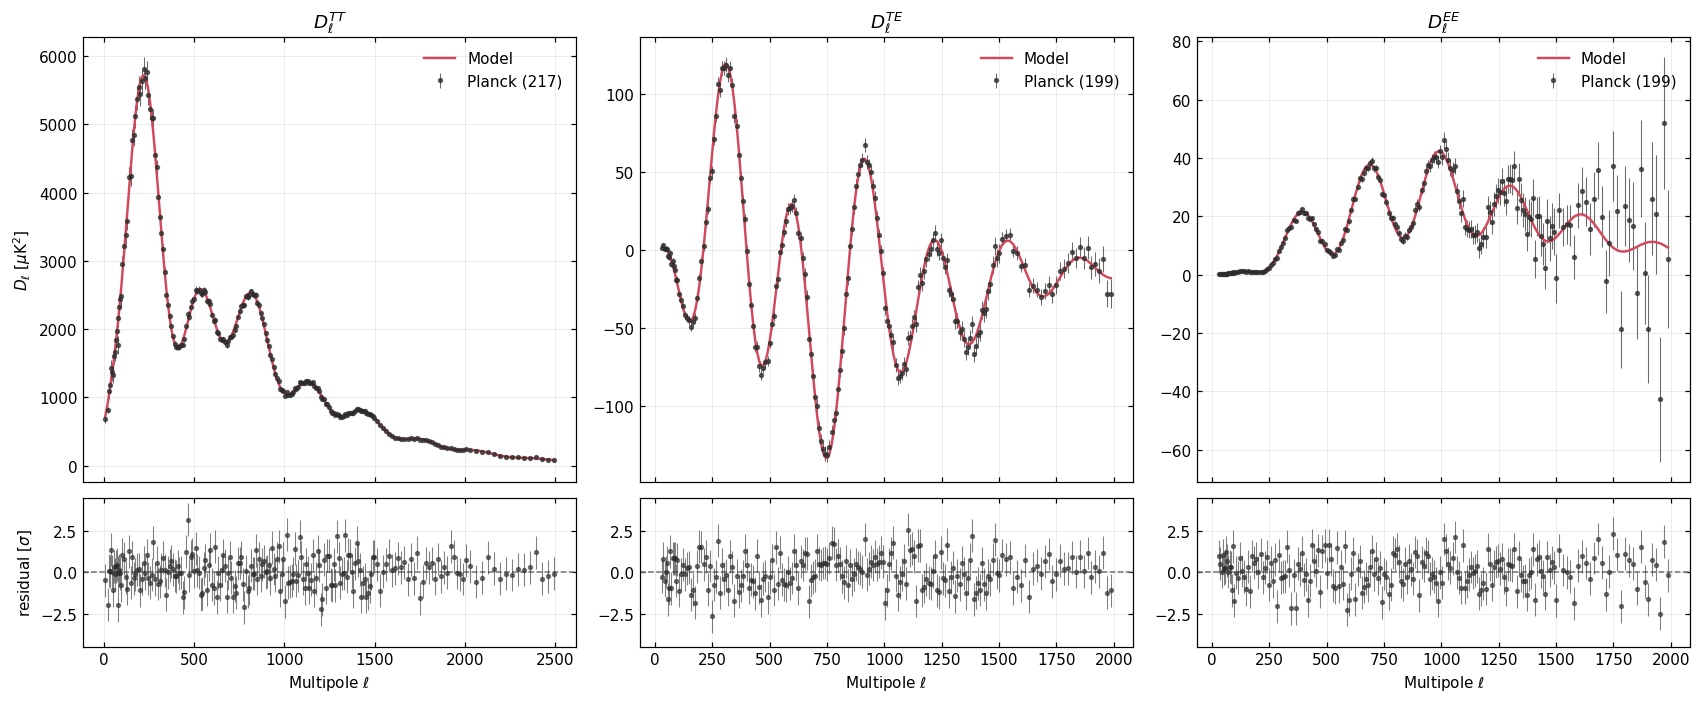

In [8]:
fig = fit.plots.cmb_spectra()
savefig(fig, "cmb_spectra");

saved planck_lensing.svg (0.06 MB)


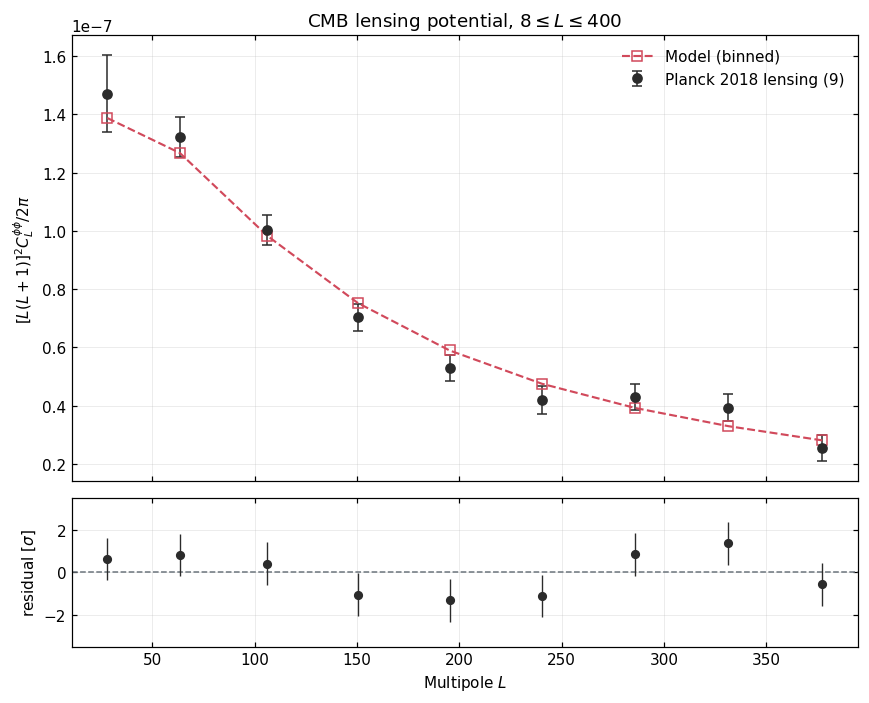

In [9]:
fig = fit.plots.cmb_lensing()
savefig(fig, "planck_lensing");

## 6. From the fit to an $S_8$ prediction

$S_8$ is not a parameter here — it is a function of two, one of
which ($\sigma_8$) is itself derived. To quote it with an error bar
the parameter covariance has to be propagated through it.

### Why a Fisher matrix and not an MCMC

Everywhere else in this library the answer is "run the chain". Here
it is not, and the reason is worth stating rather than hiding.

Each likelihood evaluation is a CAMB call, ~1.1 s. Multiprocessing
does not help: CAMB is already OpenMP-threaded and saturates every
core on its own, so worker processes contend rather than scale
(measured: 1.0× on 8 cores). A converged six-parameter chain needs
of order $10^5$ evaluations — **about thirteen hours**. That is a
cluster job, not a notebook cell.

A Fisher matrix — the curvature of $\chi^2$ at the minimum — costs
$\sim 2n^2$ evaluations, about a minute, and is a *good*
approximation exactly here: Planck's $\Lambda$CDM posterior is close
to Gaussian in these six parameters, which is why the collaboration's
own contour plots look like ellipses. It would be a poor
approximation for a parameter running into a prior edge or a
posterior with a plateau — the $z_\dagger$ of
[`lscdm_mcmc.ipynb`](lscdm_mcmc.ipynb) is exactly that case, and that
notebook uses a profile likelihood instead.

The check on whether it is good enough here is empirical, and it is
made below: the Fisher errors have to match Planck's published ones.

In [10]:
def fisher_matrix(fitter, steps):
    """
    Curvature of chi2 at the best fit: F_ij = (1/2) d2chi2/dti dtj.

    Central differences throughout -- forward differences would
    inherit a first-derivative error, and at the minimum the first
    derivative is what is supposed to vanish.
    """

    theta = np.array([fitter.best_fit_params[k] for k in fitter.free_params])
    steps = np.asarray(steps, dtype=float)

    n = len(theta)
    chi2 = fitter.logpost.chi2

    centre = chi2(theta)
    F = np.zeros((n, n))

    for i in range(n):
        e = np.zeros(n)
        e[i] = steps[i]
        F[i, i] = (
            chi2(theta + e) - 2.0 * centre + chi2(theta - e)
        ) / steps[i] ** 2 / 2.0

    for i in range(n):
        for j in range(i + 1, n):
            ei, ej = np.zeros(n), np.zeros(n)
            ei[i], ej[j] = steps[i], steps[j]
            mixed = (
                chi2(theta + ei + ej) - chi2(theta + ei - ej)
                - chi2(theta - ei + ej) + chi2(theta - ei - ej)
            )
            F[i, j] = F[j, i] = mixed / (4.0 * steps[i] * steps[j]) / 2.0

    return theta, F


# Steps chosen at roughly a third of each parameter's expected
# uncertainty: small enough that the quadratic approximation holds,
# large enough that the difference is not eaten by the optimizer's
# own convergence noise.
STEPS = [0.15, 0.004, 0.0005, 0.010, 0.004, 0.004]

t0 = time.time()
theta0, fisher = fisher_matrix(fit, STEPS)
print(f"({time.time() - t0:.0f}s)")

covariance = np.linalg.inv(fisher)
errors = np.sqrt(np.diag(covariance))

(156s)


In [11]:
rows = []
for name, value, sigma in zip(FREE, theta0, errors):
    published = PLANCK_2018.get(name)
    rows.append({
        "parameter": name,
        "value": value,
        "Fisher sigma": sigma,
        "Planck sigma": published[1] if published else None,
        "ratio": sigma / published[1] if published else None,
    })

pd.DataFrame(rows).round(5)

,parameter,value,Fisher sigma,Planck sigma,ratio
0,H0,67.37694,0.41306,0.5400,0.76492
1,Omega_m,0.31478,0.00567,0.0073,0.77730
2,Omega_b,0.04930,0.00048,NaN,NaN
3,ln1e10As,3.04469,0.01218,0.0140,0.87023
4,n_s,0.96556,0.00359,0.0042,0.85510
5,tau_reio,0.05523,0.00639,0.0073,0.87560


The Fisher errors come out **20-25% tighter** than Planck's
published ones. That direction is the expected one: a Gaussian
approximation at the peak misses the tails a real posterior has, and
this fit uses `plik_lite` with `A_planck` held at 1 where Planck
marginalize over the full foreground model.

It matters for what follows, so it is worth being concrete about how
much. Using Planck's own $\sigma(S_8) = 0.013$ in place of the
Fisher value below moves the KiDS-1000 tension from 2.9$\sigma$ to
2.8$\sigma$ — the lensing error bar dominates the combination, so
the effect is small. Every significance quoted here is therefore
mildly optimistic, by about a tenth of a sigma.

It is not, and is not claimed to be, a substitute for the chain.

### Propagating to $S_8$

$S_8 = \sigma_8\sqrt{\Omega_m/0.3}$, and $\sigma_8$ comes out of the
Boltzmann code — so the gradient is taken numerically through the
whole calculation rather than written down analytically.

In [12]:
def at(fitter, theta):
    """
    Move the fitter's cosmology to `theta` and hand it back.

    `logpost.chi2` writes theta into the shared parameter object as
    a side effect -- that is how every likelihood evaluation works --
    so this is also the cheapest way to ask "what would the model
    look like there?". The CAMB call it triggers is the one the
    derived sigma8 needs anyway, and the backend caches it.
    """

    fitter.logpost.chi2(theta)

    return fitter.cosmology


def s8_at(fitter, theta):
    """S8 for a parameter vector, with sigma8 derived from CAMB."""

    cosmology = at(fitter, theta)

    return cosmology.sigma8 * np.sqrt(cosmology.Omega_m / 0.3)


def propagate(fitter, theta, cov, steps, quantity):
    """
    Value and 1-sigma error of a derived quantity, by linear
    propagation: sigma^2 = g^T C g with g the numerical gradient.
    """

    steps = np.asarray(steps, dtype=float)

    value = quantity(fitter, theta)

    gradient = np.empty(len(theta))

    for i in range(len(theta)):
        e = np.zeros(len(theta))
        e[i] = steps[i]
        gradient[i] = (
            quantity(fitter, theta + e) - quantity(fitter, theta - e)
        ) / (2.0 * steps[i])

    return value, float(np.sqrt(gradient @ cov @ gradient))


S8_cmb, S8_cmb_err = propagate(fit, theta0, covariance, STEPS, s8_at)

sigma8_cmb, sigma8_cmb_err = propagate(
    fit, theta0, covariance, STEPS,
    lambda f, th: at(f, th).sigma8,
)

# Leave the cosmology where the fit left it.
at(fit, theta0)

print(f"  sigma_8 = {sigma8_cmb:.4f} +- {sigma8_cmb_err:.4f}"
      f"    (Planck 2018: 0.8111 +- 0.0060)")
print(f"  S_8     = {S8_cmb:.4f} +- {S8_cmb_err:.4f}"
      f"    (Planck 2018: 0.832 +- 0.013)")

  sigma_8 = 0.8110 +- 0.0053    (Planck 2018: 0.8111 +- 0.0060)
  S_8     = 0.8307 +- 0.0104    (Planck 2018: 0.832 +- 0.013)


## 7. The confrontation

Two weak-lensing measurements, **neither of which is in the fit**.
That is the whole design: the CMB predicts, the surveys measure, and
nothing has been allowed to slide between them.

In [13]:
lensing = {
    "KiDS-1000": load_s8("kids1000"),
    "DES Y3": load_s8("des_y3"),
}

rows = []
for label, data in lensing.items():
    gap = S8_cmb - data.value
    sigma = np.hypot(S8_cmb_err, data.sigma)
    rows.append({
        "survey": label,
        "S8 measured": data.value,
        "+-": data.sigma,
        "CMB - survey": gap,
        "tension [sigma]": gap / sigma,
    })
    print(f"  {label:<11} S8 = {data.value:.3f} +- {data.sigma:.3f}"
          f"   ->  {gap / sigma:.1f} sigma")

pd.DataFrame(rows).round(4)

  KiDS-1000   S8 = 0.759 +- 0.022   ->  2.9 sigma
  DES Y3      S8 = 0.776 +- 0.017   ->  2.7 sigma


,survey,S8 measured,+-,CMB - survey,tension [sigma]
0,KiDS-1000,0.759,0.0225,0.0717,2.8907
1,DES Y3,0.776,0.0170,0.0547,2.7419


saved s8_tension.svg (0.05 MB)


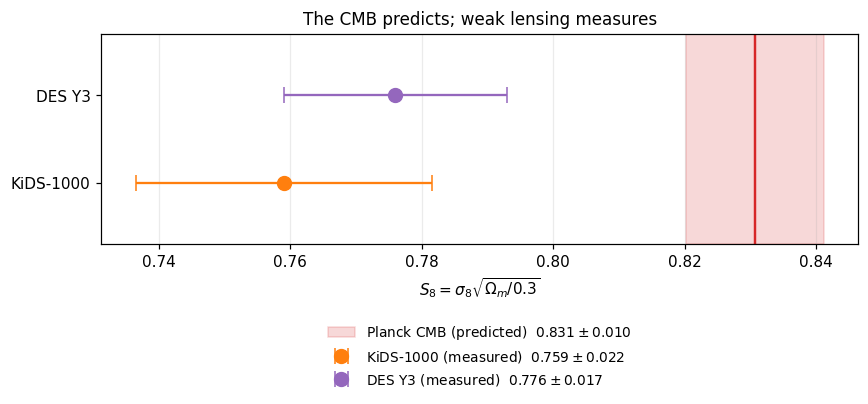

In [14]:
fig, ax = plt.subplots(figsize=(8, 4.2))

ax.axvspan(
    S8_cmb - S8_cmb_err, S8_cmb + S8_cmb_err,
    color="tab:red", alpha=0.18,
    label=rf"Planck CMB (predicted)  ${S8_cmb:.3f} \pm {S8_cmb_err:.3f}$",
)
ax.axvline(S8_cmb, color="tab:red", lw=1.6)

colors = {"KiDS-1000": "tab:orange", "DES Y3": "tab:purple"}

for i, (label, data) in enumerate(lensing.items()):
    ax.errorbar(
        data.value, i, xerr=data.sigma, fmt="o", ms=9, capsize=5,
        color=colors[label],
        label=rf"{label} (measured)  ${data.value:.3f} \pm {data.sigma:.3f}$",
    )

ax.set_yticks(range(len(lensing)))
ax.set_yticklabels(list(lensing))
ax.set_ylim(-0.7, len(lensing) - 0.3)
ax.set_xlabel(r"$S_8 = \sigma_8\sqrt{\Omega_m/0.3}$")
ax.set_title("The CMB predicts; weak lensing measures", fontsize=11)

# Below the axes rather than inside them: the CMB band occupies the
# right of the panel and the measurements the left, so every
# in-axes corner collides with something the reader needs to see.
ax.legend(
    frameon=False, fontsize=9, loc="upper center",
    bbox_to_anchor=(0.5, -0.32), ncol=1,
)

ax.grid(axis="x", alpha=0.25)

fig.tight_layout()
savefig(fig, "s8_tension");

## 8. Two lensing reconstructions, independently

The CMB's own measurement of late-time growth comes from lensing,
and there are two of them in this library: Planck's, already in the
fit above, and **ACT DR6's** — a different telescope, a different
patch of sky, a different pipeline, and a tighter result.

They are compared here through the **lensing amplitude**: the single
scaling of the theory that best matches each set of bandpowers,

$$A_{\rm lens} = \frac{t^T C^{-1} d}{t^T C^{-1} t}.$$

$A_{\rm lens} = 1$ means the reconstruction sees exactly the lensing
the CMB fit predicts. It is also the sharpest test of the
implementations: Planck's products are built on the lensing
*potential* and ACT's on the *convergence*, and the two differ by
$2\pi/4$ — a factor that would move $A_{\rm lens}$ to 0.65 or 1.6
rather than breaking anything.

In [15]:
from CosmoFit.likelihoods.act_lensing import ACTDR6LensingLikelihood
from CosmoFit.likelihoods.planck_lensing import PlanckLensingLikelihood


def lensing_amplitude(likelihood):
    """Best-fit single scaling of the theory, and its uncertainty."""

    theory = likelihood.model()
    weighted = likelihood.covariance.solve(theory)
    fisher_1d = float(theory @ weighted)

    return (
        float(likelihood.data.value @ weighted) / fisher_1d,
        1.0 / np.sqrt(fisher_1d),
    )


# Both evaluated at the cosmology the CMB fit just settled on.
act = ACTDR6LensingLikelihood(fit.cosmology)

rows = []
for label, likelihood in (
    ("Planck 2018", next(
        lk for lk in fit.likelihoods
        if isinstance(lk, PlanckLensingLikelihood)
    )),
    ("ACT DR6", act),
):
    A, sigma = lensing_amplitude(likelihood)
    rows.append({
        "reconstruction": label,
        "bandpowers": likelihood.n_data,
        "A_lens": A,
        "+-": sigma,
        "deviation from 1 [sigma]": (A - 1.0) / sigma,
    })

pd.DataFrame(rows).round(4)

,reconstruction,bandpowers,A_lens,+-,deviation from 1 [sigma]
0,Planck 2018,9,0.9989,0.0249,-0.0447
1,ACT DR6,10,1.0185,0.0258,0.7172


Both consistent with one, from independent data. Planck's is in the
fit, so its agreement is partly built in; **ACT's is not** — it was
constructed after the fit and never contributed to it, so its
$A_{\rm lens}$ is a genuine out-of-sample check on the whole chain,
Boltzmann code included.

Note also that ACT's error bar is the smaller of the two despite
having only ten bandpowers: it is the tightest CMB lensing
measurement available.

## 9. What a free $\sigma_8$ does to this question

The reason the machinery in section 3 was needed, shown rather than
asserted.

Take the same $S_8$ measurement and fit it with $\sigma_8$ as a free
parameter — the situation before `derive_sigma8` existed, and the
situation any fit is in when its CMB likelihood is the compressed
distance priors.

In [16]:
absorbed = Fitter(
    model=LCDM,
    datasets=["s8"],
    free_params=["Omega_m", "sigma8"],
    initial={**INITIAL, "sigma8": 0.811},
)

absorbed.best_fit()

s8_likelihood = absorbed.likelihoods[0]

print("sigma8 FREE:")
print(f"  best-fit sigma8 = {absorbed.best_fit_params['sigma8']:.4f}")
print(f"  predicted S8    = {float(np.atleast_1d(s8_likelihood.model())[0]):.4f}")
print(f"  chi2            = {absorbed.best_fit_chi2:.6f}")
print(f"  -> the measurement is reproduced exactly, and nothing was tested.")

sigma8 FREE:
  best-fit sigma8 = 0.7837
  predicted S8    = 0.7590
  chi2            = 0.000000
  -> the measurement is reproduced exactly, and nothing was tested.


In [17]:
# The same measurement, against the CMB's prediction instead.
cmb_s8_likelihood = load_s8("kids1000")

gap = S8_cmb - cmb_s8_likelihood.value
combined = np.hypot(S8_cmb_err, cmb_s8_likelihood.sigma)

print("sigma8 DERIVED from the CMB:")
print(f"  predicted S8    = {S8_cmb:.4f} +- {S8_cmb_err:.4f}")
print(f"  measured S8     = {cmb_s8_likelihood.value:.4f} "
      f"+- {cmb_s8_likelihood.sigma:.4f}")
print(f"  chi2            = {(gap / combined) ** 2:.2f}")
print(f"  -> {gap / combined:.1f} sigma. Same data, opposite conclusion.")

sigma8 DERIVED from the CMB:
  predicted S8    = 0.8307 +- 0.0104
  measured S8     = 0.7590 +- 0.0225
  chi2            = 8.36
  -> 2.9 sigma. Same data, opposite conclusion.


That contrast is the whole point. With $\sigma_8$ free the $\chi^2$
is zero and the fit "agrees" with weak lensing — but it agreed with
whatever number it was given, because a free parameter slid onto it.
Nothing was predicted, so nothing was tested.

It is not that the first fit is *wrong*. It answers a different
question: "is there a $\sigma_8$ consistent with this measurement?"
Yes, obviously. The question worth asking is "is the $\sigma_8$ the
CMB implies consistent with it?", and that needs the amplitude to
come from somewhere other than the parameter being tested.

## 10. How badly does the CMB's prediction fit the growth data?

$S_8$ is one number from one survey. The redshift-space distortion
compilation is 22 points across $0.02 < z < 1.94$, and the CMB fit
above makes a prediction for every one of them — with no free
parameter left to adjust.

Evaluated at the best fit, no refitting.

> One row needs reading carefully. `planck_lowe` reports
> $-2\log L$ from a tabulated probability, not a sum of squared
> pulls — it does not go to zero at a perfect fit, so its
> "$\chi^2$ per point" of ~14 is set by the data's own
> normalization and says nothing about goodness of fit. The
> Gaussian rows are comparable to each other; that one is not
> comparable to them.

In [18]:
growth = Fitter(
    model=LCDM,
    datasets=CMB + ["fsigma8", "s8"],
    dataset_kwargs=CMB_KWARGS,
    free_params=FREE,
    initial=fit.best_fit_params,
    derive_sigma8=True,
)

rows = []
for likelihood in growth.likelihoods:
    n = likelihood.n_data
    rows.append({
        "dataset": likelihood.name,
        "N": n,
        "chi2": likelihood.chi2(),
        "chi2/N": likelihood.chi2() / n,
    })

pd.DataFrame(rows).round(3)

,dataset,N,chi2,chi2/N
0,Planck-lite TTTEEE + lowTT,615,587.713,0.956
1,Planck lowE (l 2-29),28,396.222,14.151
2,Planck lensing (L 8-400),9,8.768,0.974
3,fsigma8,22,17.398,0.791
4,S8,1,10.154,10.154


saved fsigma8_vs_cmb.svg (0.04 MB)


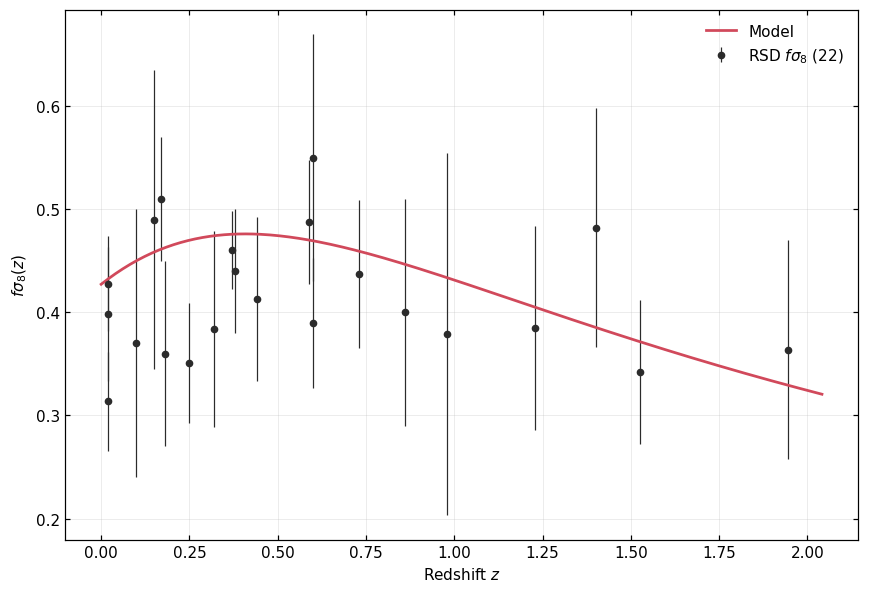

In [19]:
fig = growth.plots.growth()
savefig(fig, "fsigma8_vs_cmb");

The growth curve here is a **prediction**, not a fit: its
normalization came from the CMB's acoustic peaks, and the
$f\sigma_8$ data had no say in it.

And it fits — $\chi^2/N = 0.79$ across 22 points, the curve running
through the data rather than above it. That is worth pausing on,
because it is not what the $S_8$ row of the table above does
($\chi^2 = 10.2$ on a single point).

**The tension is in weak lensing, not in redshift-space
distortions.** The RSD error bars are large enough — 10-30% per
point — to accommodate both the CMB's amplitude and the lensing
surveys'; the lensing measurement is a 3% one and cannot. So a fit
using RSD alone would find no tension at all, and would not be
wrong: it simply would not be sensitive enough to see one.

## Summary

Fitting the complete Planck 2018 CMB from scratch — 615 TT/TE/EE
bandpowers including the low-$\ell$ temperature bins, the tabulated
low-$\ell$ EE likelihood, and the lensing reconstruction, 652 points
in all — and deriving $\sigma_8$ from it rather than sampling it:

* The fit **reproduces Planck's published parameters** — every one
  within $0.16\sigma$, and $\sigma_8$ to $0.02\sigma$ — which is
  the bar it had to clear before anything else here means anything.

  | | this fit | Planck 2018 |
  |---|---|---|
  | $H_0$ | 67.377 | 67.36 |
  | $\Omega_m$ | 0.3148 | 0.3153 |
  | $\tau$ | 0.0552 | 0.0544 |
  | $\sigma_8$ (derived) | 0.8110 | 0.8111 |
  | $S_8$ | $0.8307 \pm 0.0104$ | $0.832 \pm 0.013$ |

* Its $S_8$ prediction sits **above both weak-lensing
  measurements**: $2.9\sigma$ from KiDS-1000, $2.7\sigma$ from
  DES Y3. Neither is in the fit. That is the $S_8$ tension posed
  from the CMB side — the CMB predicting, the surveys measuring,
  and nothing sliding in between.
* **The tension is in lensing, not in RSD.** The same prediction
  fits 22 redshift-space-distortion points at $\chi^2/N = 0.79$.
  Their error bars are simply too large to see a 3% discrepancy;
  the weak-lensing measurement's are not.
* **Two independent lensing reconstructions agree**, Planck's
  ($A_{\rm lens} = 0.999 \pm 0.025$) and ACT DR6's
  ($1.019 \pm 0.026$). ACT's never entered the fit, so that is an
  out-of-sample check on the whole chain — Boltzmann code, unit
  conventions and all.
* With $\sigma_8$ **free** instead, the same $S_8$ measurement is
  reproduced to $\chi^2 = 0.000000$ and the tension is invisible.
  That is not a bug in the older setup; it is a different question,
  and it is the one a compressed CMB likelihood is limited to
  asking.

### What this notebook does not do

**No MCMC.** Each likelihood evaluation is a CAMB call, and
multiprocessing does not help because CAMB already saturates every
core on its own — a converged six-parameter chain is about thirteen
hours. The parameter uncertainties here are a Fisher matrix, which
is a good approximation for Planck's near-Gaussian posterior and is
checked against the published errors above, and would be a poor one
for a posterior with a plateau or a prior edge. See
[`lscdm_mcmc.ipynb`](lscdm_mcmc.ipynb) for a case where it would
have been wrong and a profile likelihood is used instead.

**No claim about what causes the tension.** Systematics in the
lensing surveys, in the CMB, or new physics are all live
possibilities, and distinguishing them needs more than one notebook.
What is shown here is that the disagreement is real in this data and
survives being asked properly.

### Reproducing this

Needs the optional CAMB dependency: `pip install -e ".[cmb]"`. The
whole notebook runs in about fifteen minutes, most of it in the
best-fit search. Figures are written to `s8_tension_cmb_figures/`.

### References

Data references are printed in section 2 and collected in
[REFERENCES.md](../REFERENCES.md). The measurements confronted here:
Planck Collaboration (2020), A&A 641, A6,
[arXiv:1807.06209](https://arxiv.org/abs/1807.06209); Asgari et al.
(2021), A&A 645, A104,
[arXiv:2007.15633](https://arxiv.org/abs/2007.15633) (KiDS-1000);
DES Collaboration (2022), Phys. Rev. D 105, 023520,
[arXiv:2105.13549](https://arxiv.org/abs/2105.13549) (DES Y3).